## Import Packages

In [12]:
# general
import numpy as np
import pandas as pd
import os

# plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#

# my functions/classes
import sys
sys.path.append("../core_scripts/")
from ECMclass import ECM

## User Inputs

In [13]:
# smoothing window, mm
window = 10

# paths
global path_to_data, path_to_figures, path_to_metadata, metadata_file
path_to_data = '../../data/'
path_to_figures = '../../figures/'
path_to_metadata = '../../data/'
metadata_file = 'metadata.csv'

In [14]:
# set globals
global meta, my_cmap

# Load metadata
meta = pd.read_csv(path_to_data+metadata_file)

# make colormap
my_cmap = matplotlib.colormaps['Spectral']

In [15]:
path_to_figures

'../../figures/'

## Functions

In [16]:
def plotquarter(y_vec,ycor,d,meas,button,axs,rescale,res = 0.002):
    
    width = y_vec[1] - y_vec[0]
    
    for y in y_vec:
        
        idx = ycor==y
        
        tmeas = meas[idx]
        tbut = button[idx]
        tycor = ycor[idx]
        td = d[idx]

        #downsample ECM to save plotting time (as needed)
        int_lo = round(min(td),2)
        int_hi = round(max(td),2)
        depth_interp = np.linspace(int_lo,int_hi,int((int_hi-int_lo)/res)+1)
        meas_interp = np.interp(depth_interp,np.flip(td),np.flip(tmeas))
        but_interp = np.interp(depth_interp,np.flip(td),np.flip(tbut))
        td = depth_interp
        tmeas = meas_interp
        tbut = np.round(but_interp)
        
        for i in range(len(tmeas)-1):
            
            if tbut[i] == 0:
                
                axs.add_patch(Rectangle((y-(width-0.2)/2,td[i]),(width-0.2),td[i+1]-td[i],facecolor=my_cmap(rescale(tmeas[i]))))
            else:
                axs.add_patch(Rectangle((y-(width-0.2)/2,td[i]),(width-0.2),td[i+1]-td[i],facecolor='k'))
            
    return()

In [ ]:
def plot_basic(core):

    print(path_to_data)

    # check that path_to_figures+core exists, if not create it
    if not os.path.exists(path_to_figures+core):
        os.makedirs(path_to_figures+core)

    # filter metadata for the core of interest
    core_meta = meta[meta['core'] == core]

    # get list of unique sections for the core
    sections = core_meta['section'].unique()

    # loop though sections and plot each one
    cnt = 0
    for section in sections:

        #print(f"Plotting {core} section {section}, {cnt} of {len(sections)}")
        # progress bar here, including update on current section

        section_meta = core_meta[core_meta['section'] == section]

        # get list of unique faces for the core
        faces = section_meta['face'].unique()

        # load ecm data for the section
        data = []
        for index,row in section_meta.iterrows():
            #print("    Loading ECM data for core: {}, section: {}, face: {}, ACorDC: {}".format(row['core'],row['section'],row['face'],row['ACorDC']))

            # check if filename exists in ../../data/clean/[core]/
            if os.path.exists(path_to_data+'clean/'+row['core']+'/'+row['core']+'-'+row['section']+'-'+row['face']+'-'+row['ACorDC']+'.csv'):
                path_to_file = path_to_data+'clean/'
            else:
                path_to_file = path_to_data+'not-cleaned/'
            data_item = ECM(row['core'],row['section'],row['face'],row['ACorDC'],path_to_file,path_to_metadata + metadata_file)
            data_item.rem_ends(10)
            data_item.smooth(window)
            data_item.norm_all()
            #data_item.norm_outside()
            data.append(data_item)

        # find min and max depths
        minvec = []
        maxvec = []
        for data_face in data:
            minvec.append(min(data_face.depth))
            maxvec.append(max(data_face.depth))
        dmin = min(minvec)
        dmax = max(maxvec)

        # get AC and data rescale
        # NOTE: NEED TO DEAL WITH BUTTON!!!
        AC_all = []
        DC_all = []
        for data_face in data:
            mask = data_face.button == 0
            if data_face.ACorDC == 'AC':
                AC_all.extend(data_face.meas[mask])
            else:
                DC_all.extend(data_face.meas[mask])
        ACpltmin = np.percentile(AC_all,5)
        ACpltmax = np.percentile(AC_all,95)
        DCpltmin = np.percentile(DC_all,5)
        DCpltmax = np.percentile(DC_all,95)  
        ACrescale = lambda k: (k-ACpltmin) /  (ACpltmax-ACpltmin)
        DCrescale = lambda k: (k-DCpltmin) /  (DCpltmax-DCpltmin)
        
        # now fill in the data (calls sub-fucntion based on the cut)
        if ['r'] in faces:
            fig, axs = plot_tr(data,dmin,dmax,ACrescale,DCrescale)
        elif ['l'] in faces:
            fig, axs = plot_tl(data,dmin,dmax,ACrescale,DCrescale)
        elif ['w2'] in faces and ['w1'] in faces:
            fig, axs = plot_w1w2(data,dmin,dmax,ACrescale,DCrescale)
        elif ['w1'] in faces and ['w2'] not in faces:
            fig, axs = plot_w1(data,dmin,dmax,ACrescale,DCrescale)

        # finish figure
        fig.suptitle(f"{core} section {section}")
        fig.tight_layout()
        plt.subplots_adjust(wspace=0)

        # add colorbar
        ACcbar_ax = fig.add_axes([0.07,-0.05,0.35,0.05])
        ACnorm = matplotlib.colors.Normalize(vmin=ACpltmin,vmax=ACpltmax)
        DCcbar_ax = fig.add_axes([0.58,-0.05,0.35,0.05])
        DCnorm = matplotlib.colors.Normalize(vmin=DCpltmin,vmax=DCpltmax)
        ACcbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=ACnorm, cmap=my_cmap),cax=ACcbar_ax,
                    orientation='horizontal',label='Current (amps)')
        DCcbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=DCnorm, cmap=my_cmap),cax=DCcbar_ax,
                    orientation='horizontal',label='Current (amps)')


        # save figure
        fname = path_to_figures+core+'/'+core+'-'+section+'.png'
        fig.savefig(fname,bbox_inches='tight')

        
        cnt+=1

In [24]:
def plot_tr(data,dmin,dmax,ACrescale,DCrescale):
    print("Hello World")

In [25]:
def plot_tl(data,dmin,dmax,ACrescale,DCrescale):
    print("Hello World")

In [40]:
def plot_w1w2(data,dmin,dmax,ACrescale,DCrescale):

    # make figure
    fig, axs = plt.subplots(1, 5, gridspec_kw={'width_ratios': [3, 3,3, 3, 3]},figsize=(9,6),dpi=100)

    # assign faces
    AC_w1 = None
    AC_w2 = None
    DC_w1 = None
    DC_w2 = None
    for d in data:
        if d.ACorDC == 'AC':
            if d.face == 'w1':
                AC_w1 = d
            if d.face == 'w2':
                AC_w2 = d
        else:
            if d.face == 'w1':
                DC_w1 = d
            if d.face == 'w2':
                DC_w2 = d

    # right-specific
        for a in [axs[0],axs[3]]:
            #a.yaxis.tick_right()
            a.set_xlim([55, 0])

    # top specific
    for a in [axs[1],axs[4]]:
        a.yaxis.tick_right()
        a.yaxis.set_label_position("right")
        a.set_xlim([0,55])
        
    # applies to all
    for a in [axs[0],axs[1],axs[3],axs[4]]:
        a.set_ylabel('Depth (m)')
        a.set_xlabel('Distance From Center (mm)',fontsize=6)
        a.set_ylim([dmax, dmin])

    for a,data_face in zip([axs[0],axs[1],axs[3],axs[4]],[AC_w2,AC_w1,DC_w2,DC_w1]):
        
        if data_face != None:
            if data_face.face == 'w2':
                yall = data_face.y_s - data_face.y_left
                yvec = data_face.y_vec - data_face.y_left
            else:
                yall = data_face.y_right - data_face.y_s
                yvec = data_face.y_right - data_face.y_vec
            
            if data_face.ACorDC =='AC':
                rescale = ACrescale
            else:
                rescale = DCrescale
        
            # plot data
            plotquarter(yvec,
                        yall,
                        data_face.depth_s,
                        data_face.meas_s,
                        data_face.button_s,
                        a,
                        rescale)

    return fig, axs


In [41]:
def plot_w1(data,dmin,dmax,ACrescale,DCrescale):

    # Make figure
    fig, axs = plt.subplots(1, 3, gridspec_kw={'width_ratios': [3,1, 3]},figsize=(9,6),dpi=100)

    # Assign faces
    AC_w1 = None
    DC_w1 = None
    for d in data:
        if d.ACorDC == 'AC':
            if d.face == 'w1':
                AC_w1 = d
        else:
            if d.face == 'w1':
                DC_w1 = d

    
    for a in [axs[0],axs[2]]:
        a.set_xlim([55,0])
        a.set_xlabel('Distance From O Line (mm)',fontsize=6)
        a.set_ylim([dmax, dmin])
        a.set_ylabel('Depth (m)')
        
        
    for a,data_face in zip([axs[0],axs[2]],[AC_w1,DC_w1]):
        
        if data_face != None:

            yall = data_face.y_right - data_face.y_s
            yvec = data_face.y_right - data_face.y_vec
            
            if data_face.ACorDC =='AC':
                rescale = ACrescale
            else:
                rescale = DCrescale
        
            # plot data
            plotquarter(yvec,
                        yall,
                        data_face.depth_s,
                        data_face.meas_s,
                        data_face.button_s,
                        a,
                        rescale)


    # housekeeping
    axs[1].axis('off')
    axs[0].set_title('AC - W1')
    axs[2].set_title('DC - W1')

    return fig, axs

../../data/
Plotting ALHIC2401 section 1, 0 of 39
    Loading ECM data for core: ALHIC2401, section: 1, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 1, face: w1, ACorDC: DC
    Loading ECM data for core: ALHIC2401, section: 1, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 1, face: w2, ACorDC: DC
Plotting ALHIC2401 section 10, 1 of 39
    Loading ECM data for core: ALHIC2401, section: 10, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 10, face: w1, ACorDC: DC
    Loading ECM data for core: ALHIC2401, section: 10, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 10, face: w2, ACorDC: DC


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting ALHIC2401 section 13, 2 of 39
    Loading ECM data for core: ALHIC2401, section: 13, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 13, face: w1, ACorDC: DC
    Loading ECM data for core: ALHIC2401, section: 13, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 13, face: w2, ACorDC: DC


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting ALHIC2401 section 14, 3 of 39
    Loading ECM data for core: ALHIC2401, section: 14, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 14, face: w1, ACorDC: DC


...

    Loading ECM data for core: ALHIC2401, section: 54, face: w2, ACorDC: DC
Plotting ALHIC2401 section 55, 35 of 39
    Loading ECM data for core: ALHIC2401, section: 55, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 55, face: w1, ACorDC: DC
    Loading ECM data for core: ALHIC2401, section: 55, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 55, face: w2, ACorDC: DC


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting ALHIC2401 section 57, 36 of 39
    Loading ECM data for core: ALHIC2401, section: 57, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 57, face: w1, ACorDC: DC


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


    Loading ECM data for core: ALHIC2401, section: 57, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 57, face: w2, ACorDC: DC
Plotting ALHIC2401 section 61, 37 of 39
    Loading ECM data for core: ALHIC2401, section: 61, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 61, face: w1, ACorDC: DC
    Loading ECM data for core: ALHIC2401, section: 61, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 61, face: w2, ACorDC: DC
Plotting ALHIC2401 section 9, 38 of 39
    Loading ECM data for core: ALHIC2401, section: 9, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 9, face: w1, ACorDC: DC
    Loading ECM data for core: ALHIC2401, section: 9, face: w2, ACorDC: AC
    Loading ECM data for core: ALHIC2401, section: 9, face: w2, ACorDC: DC


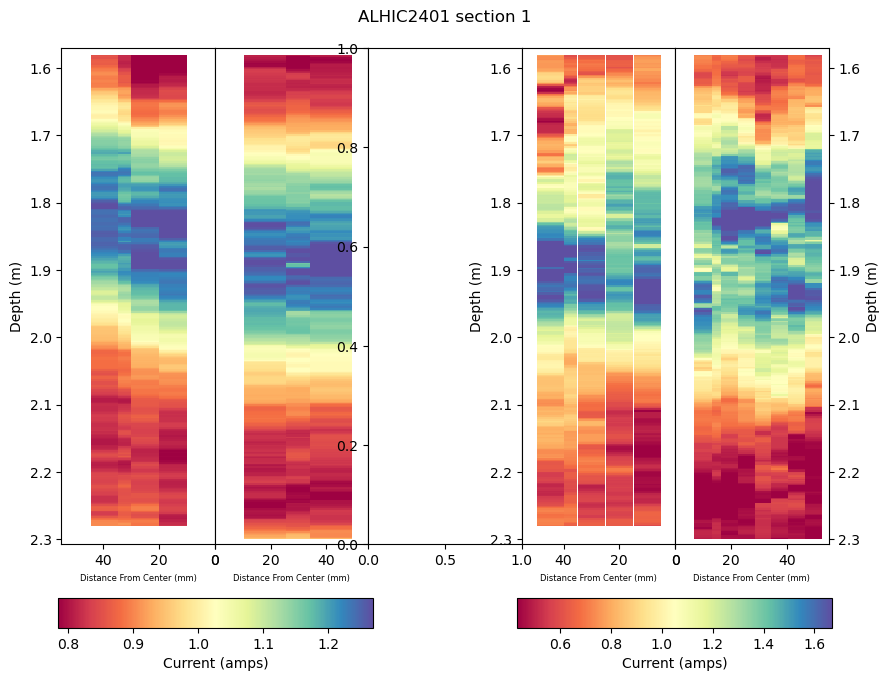

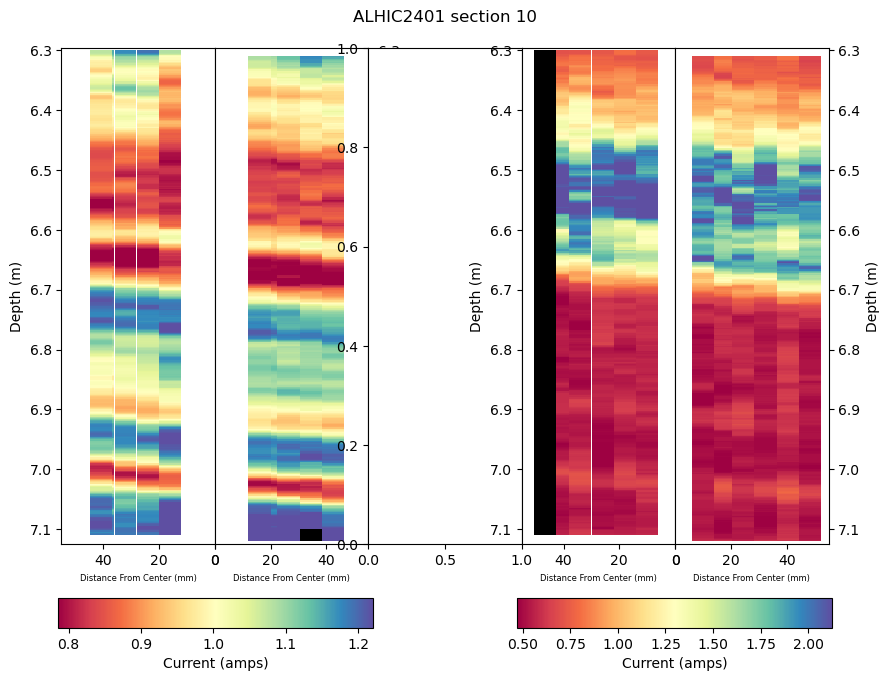

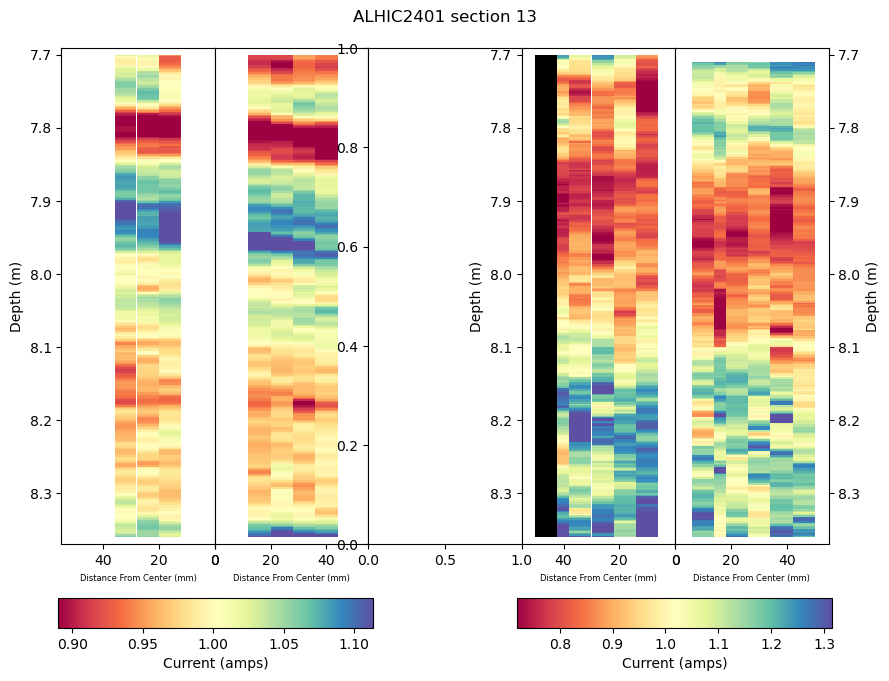

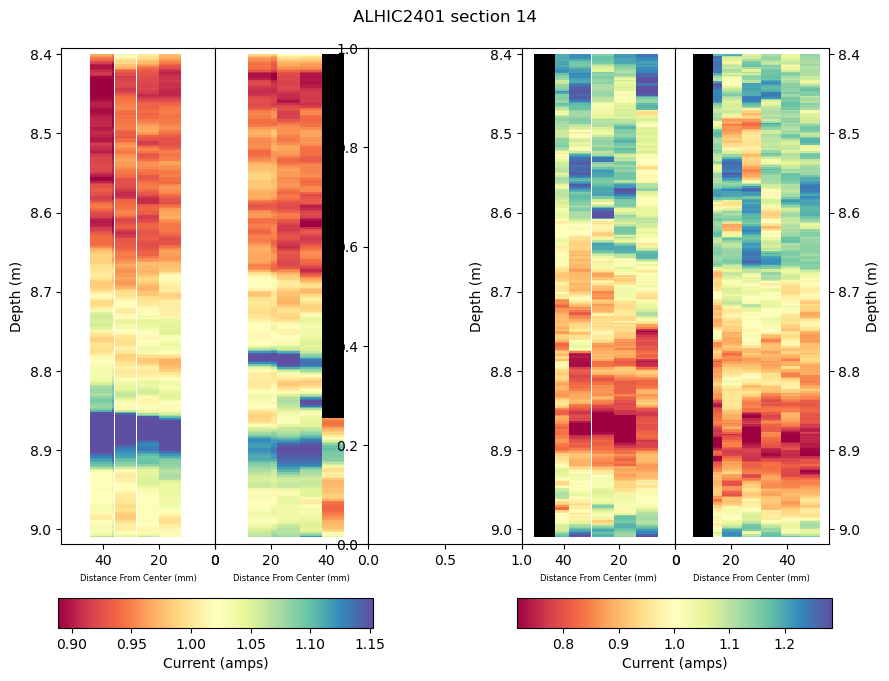

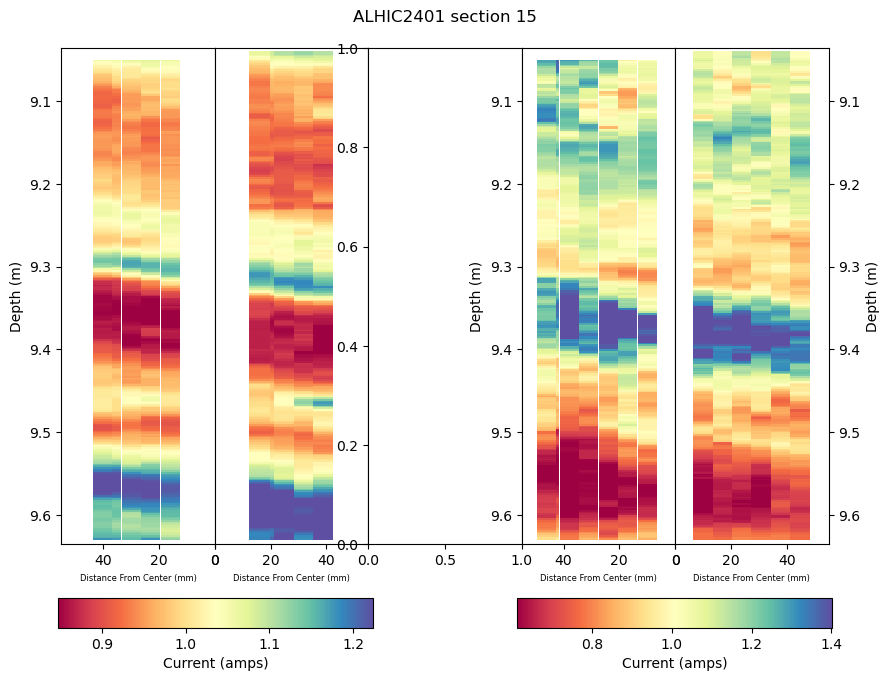

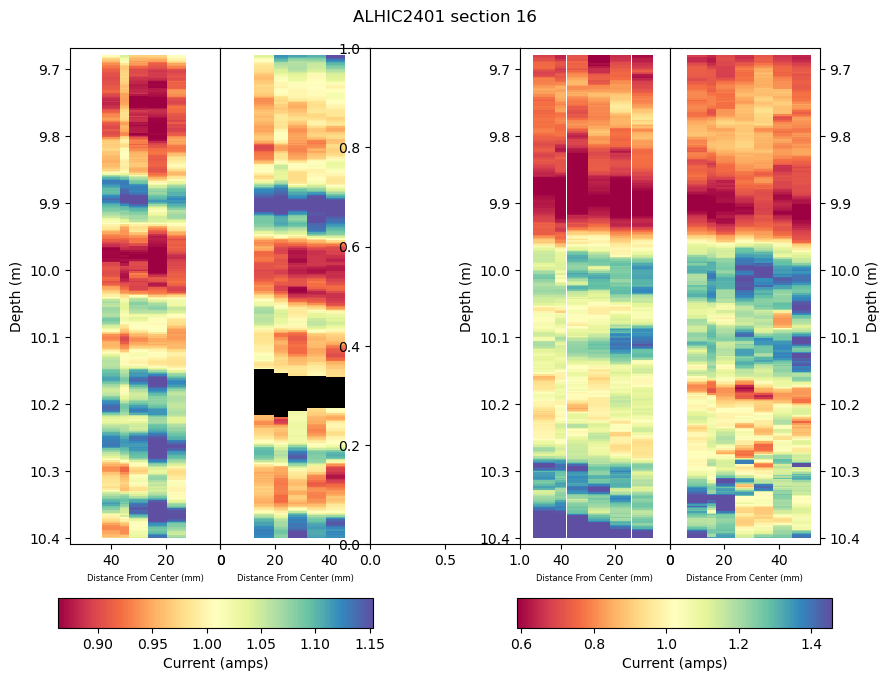

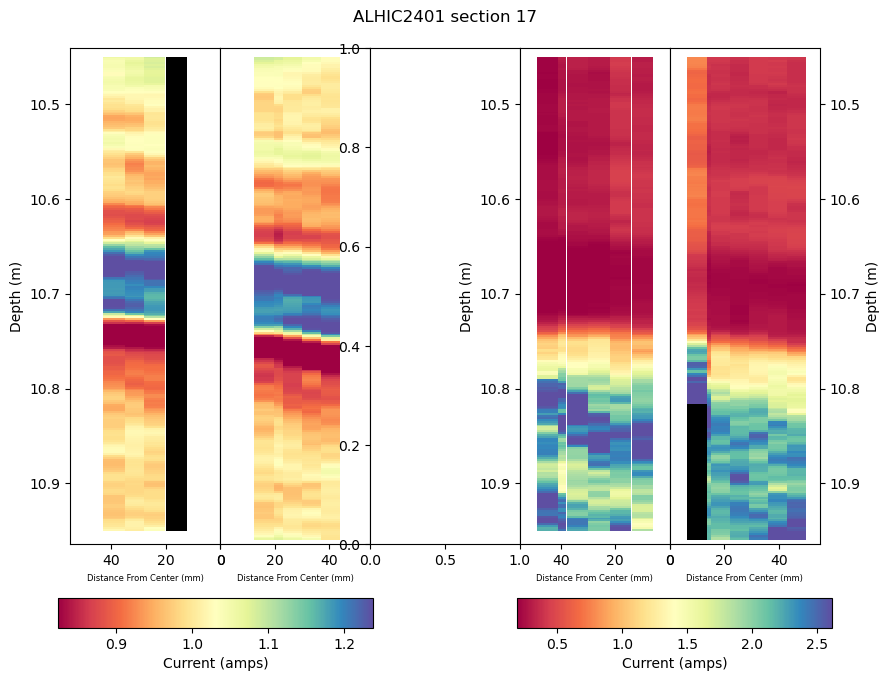

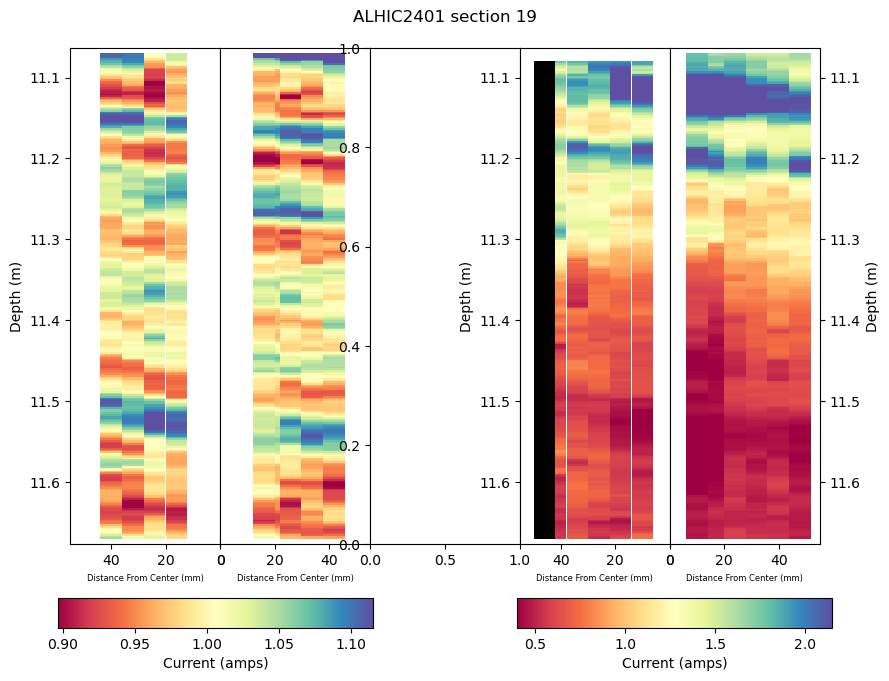

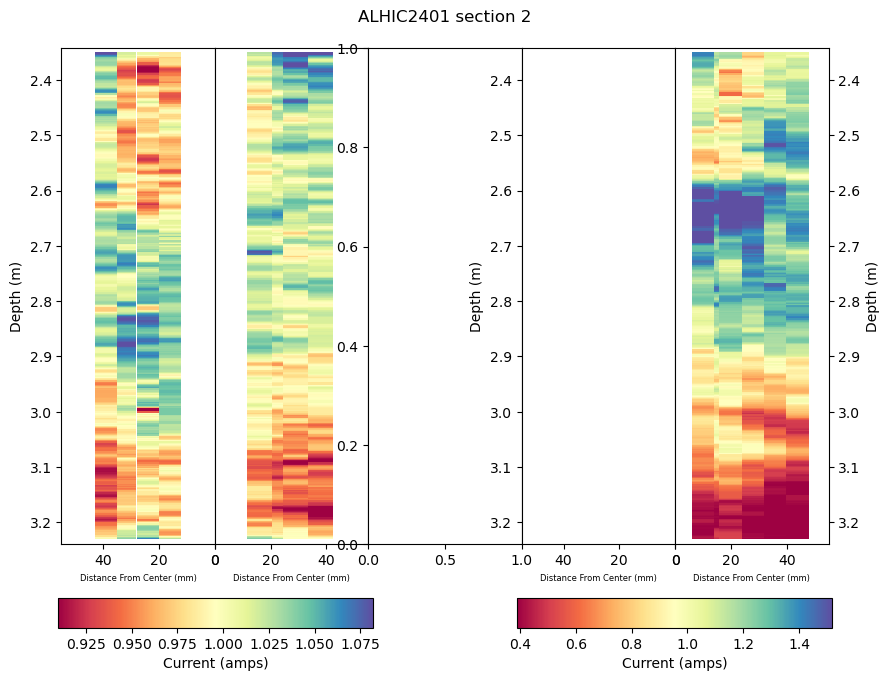

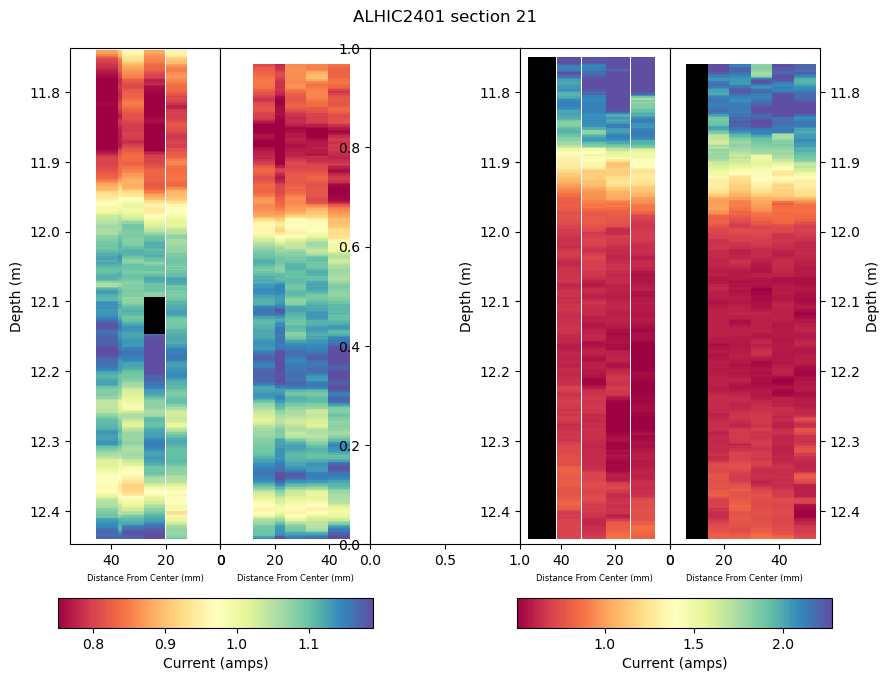

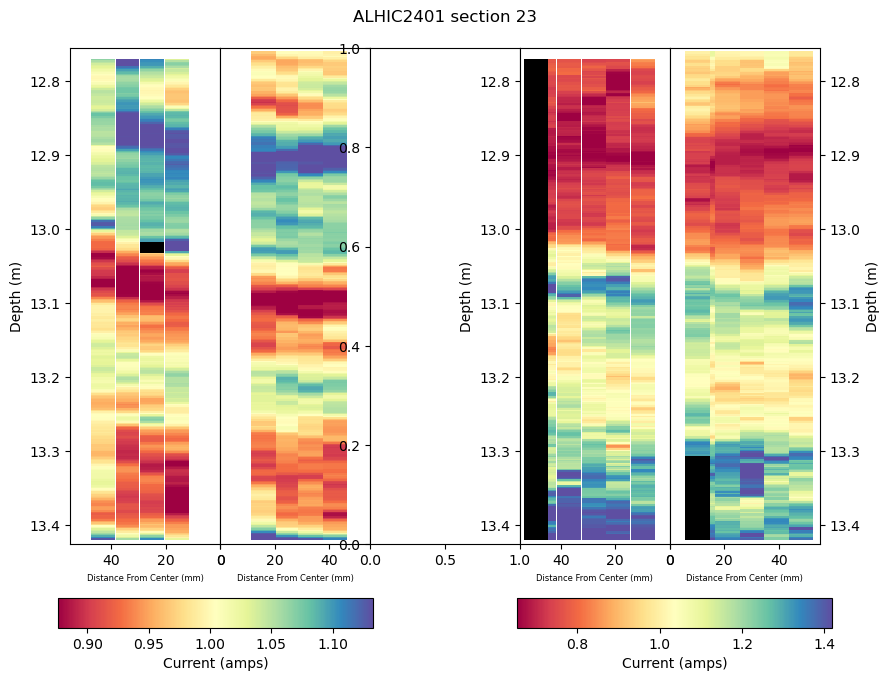

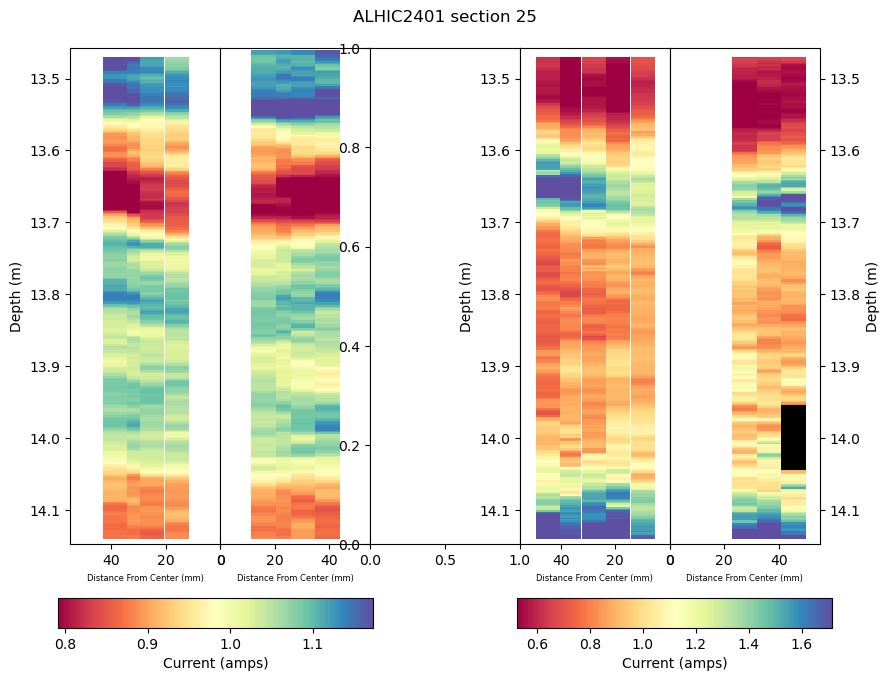

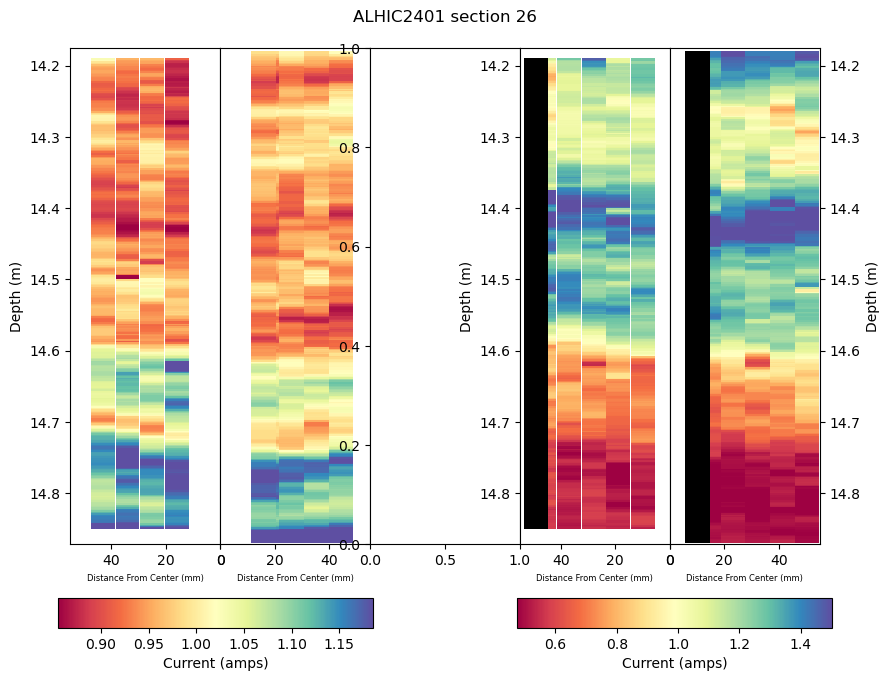

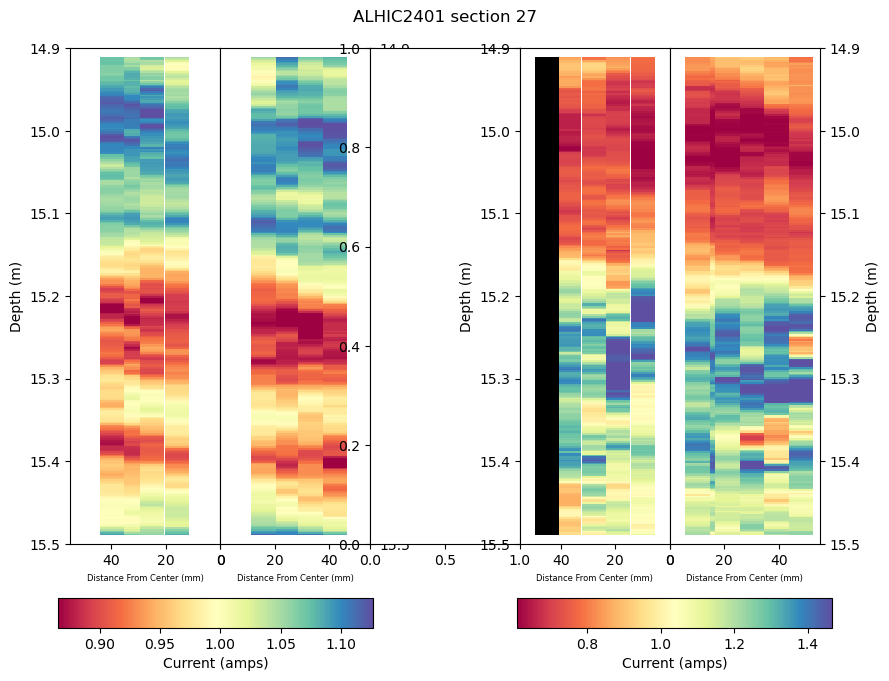

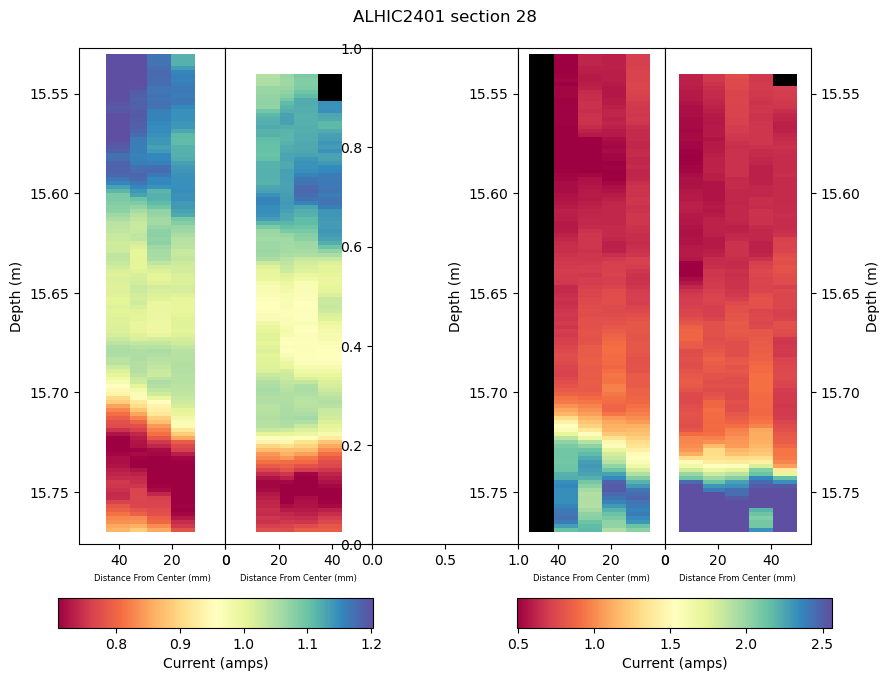

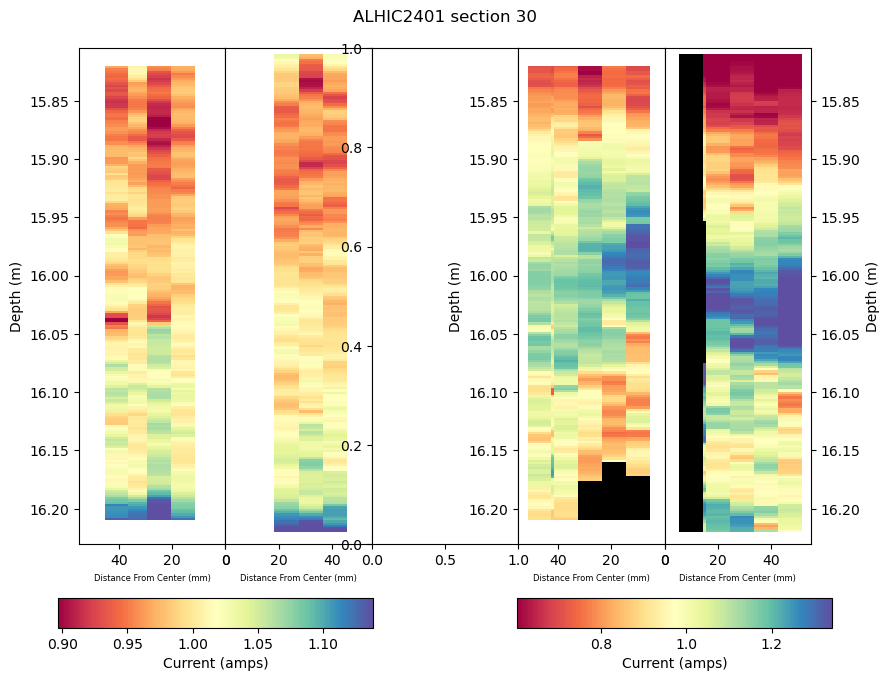

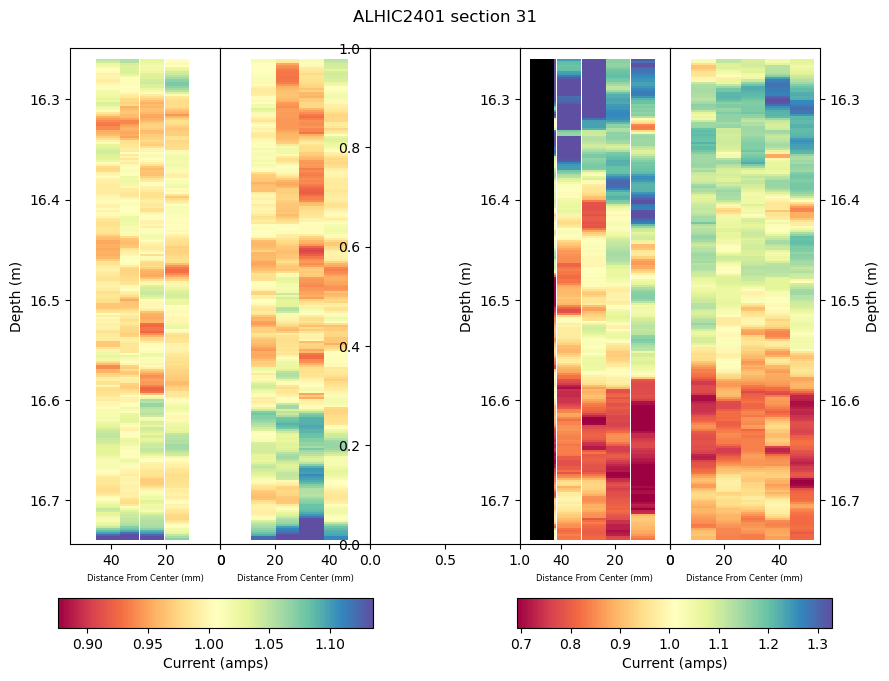

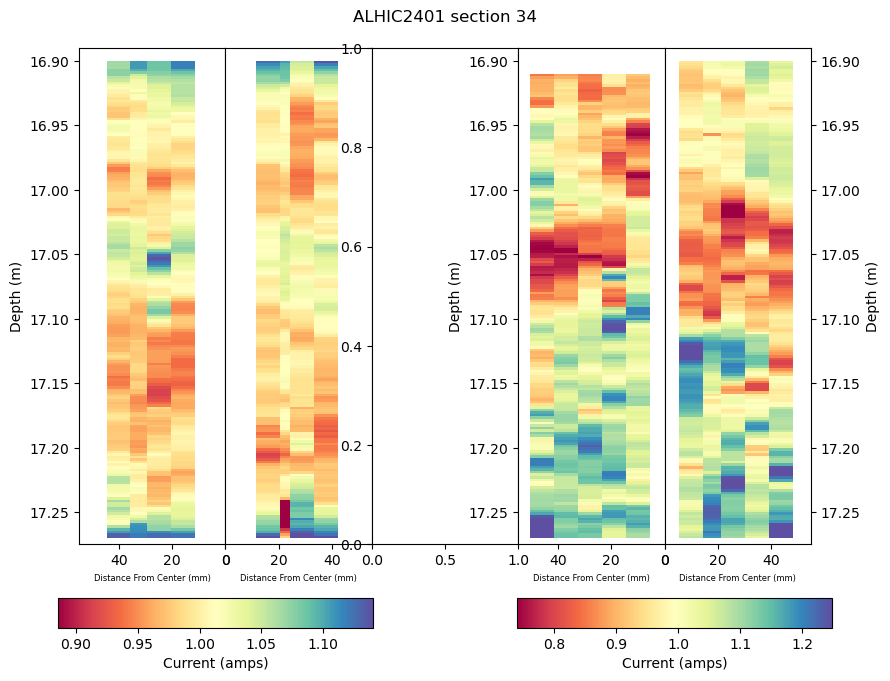

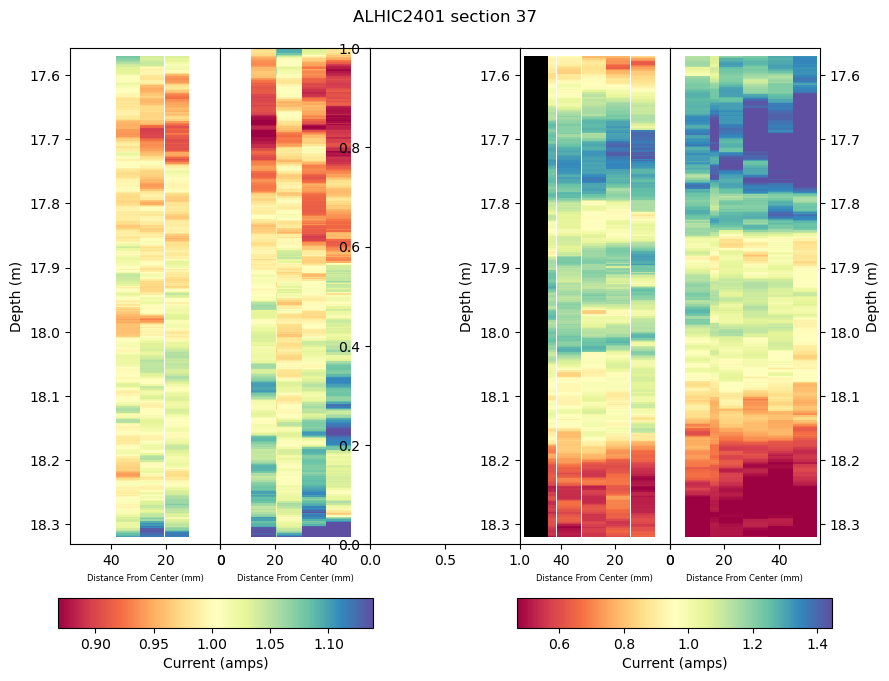

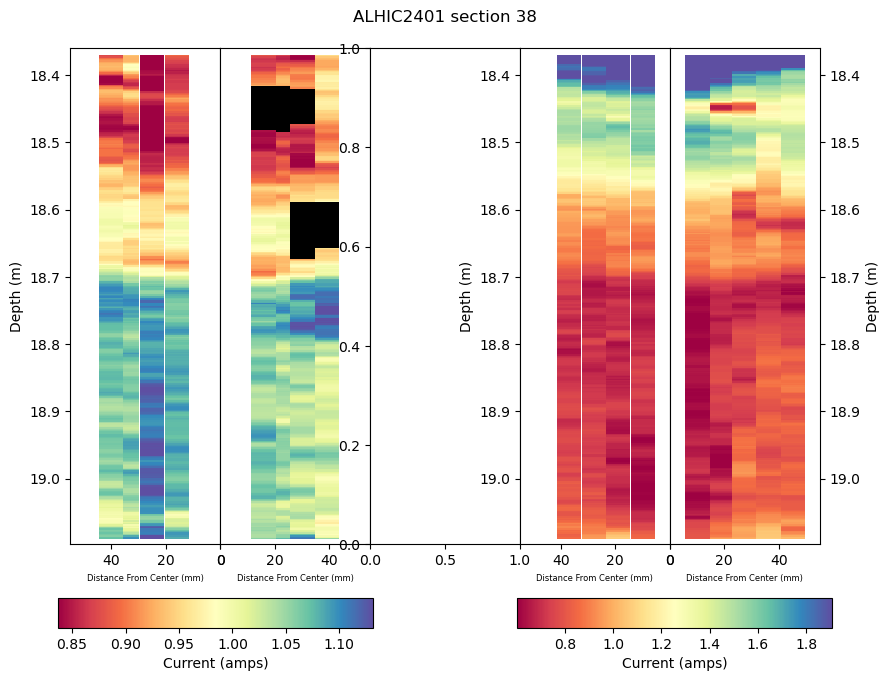

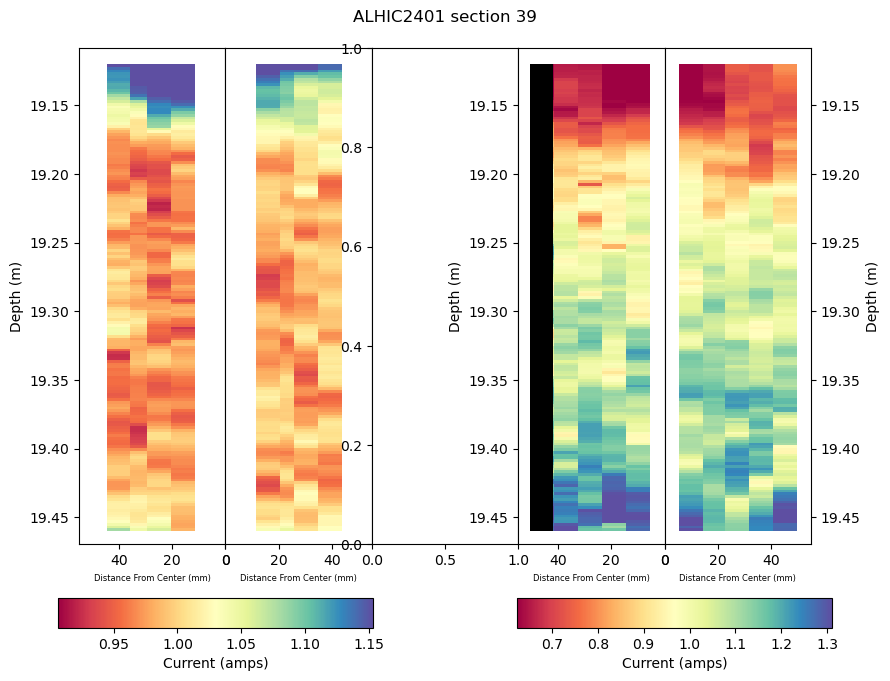

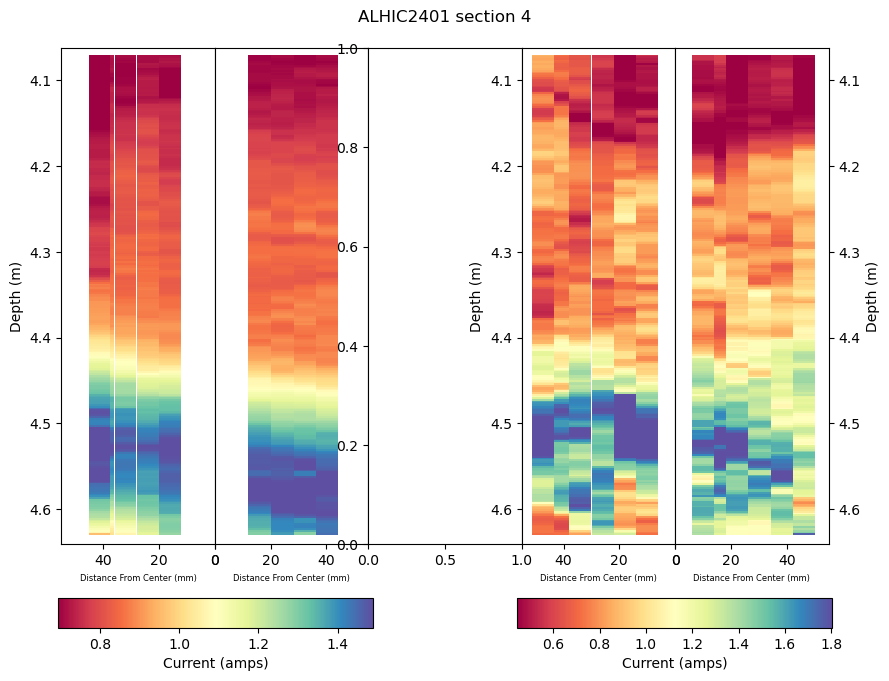

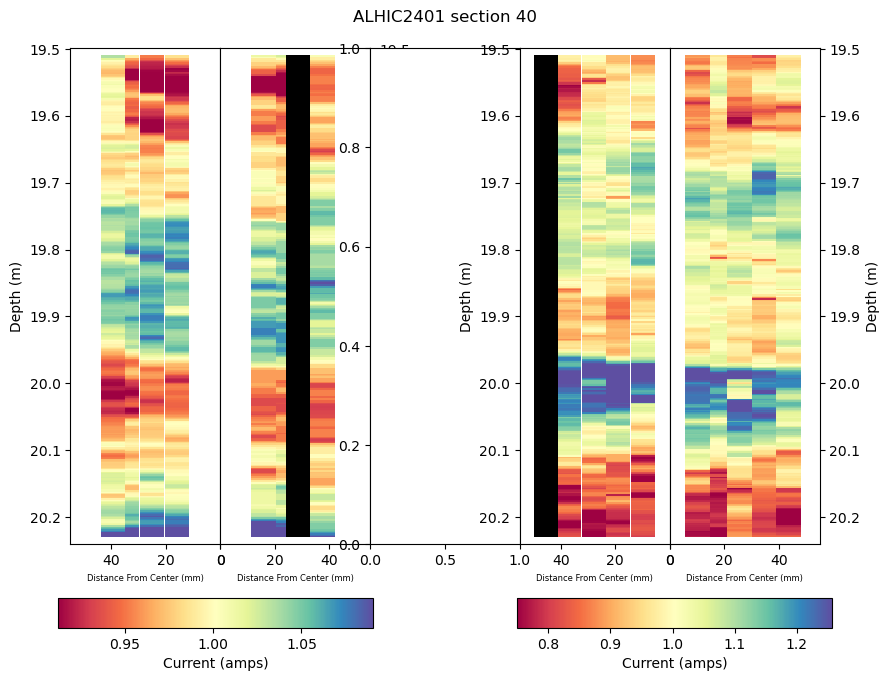

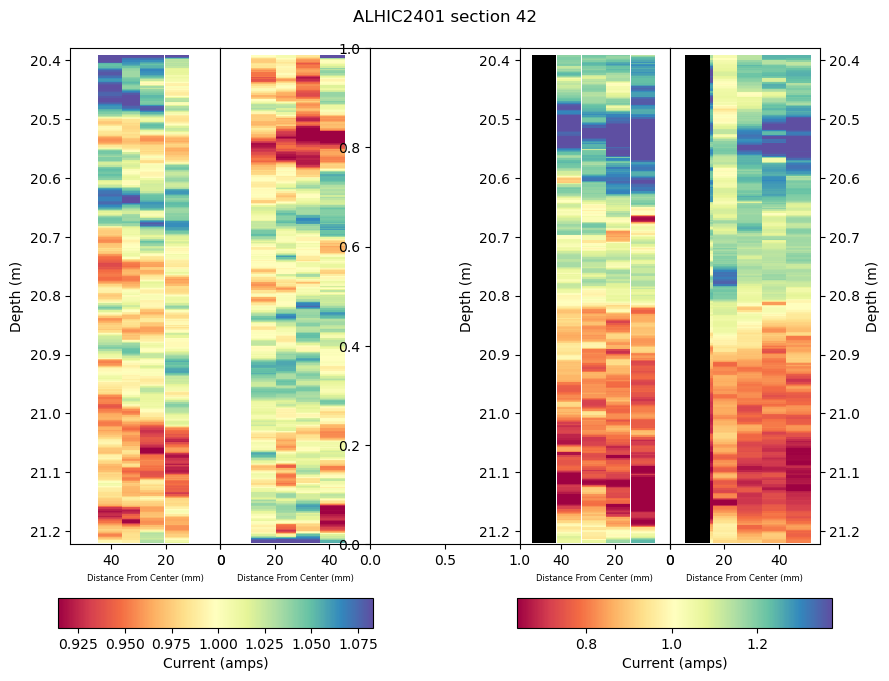

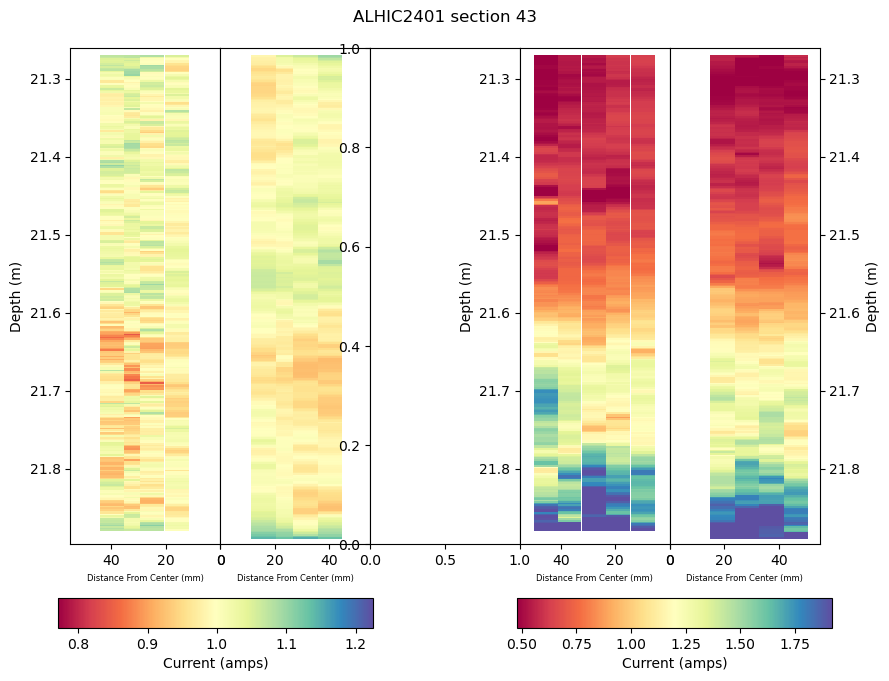

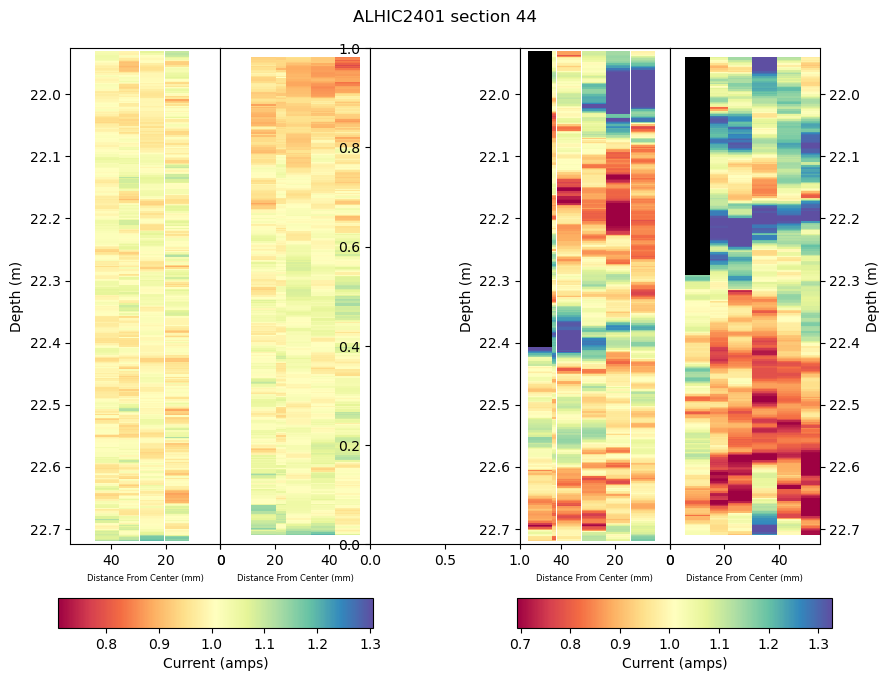

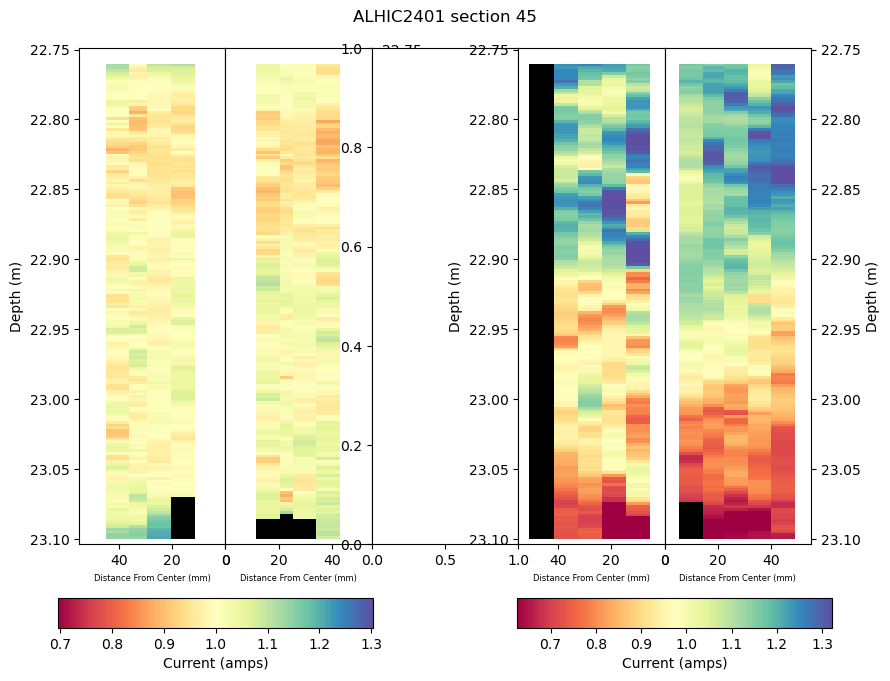

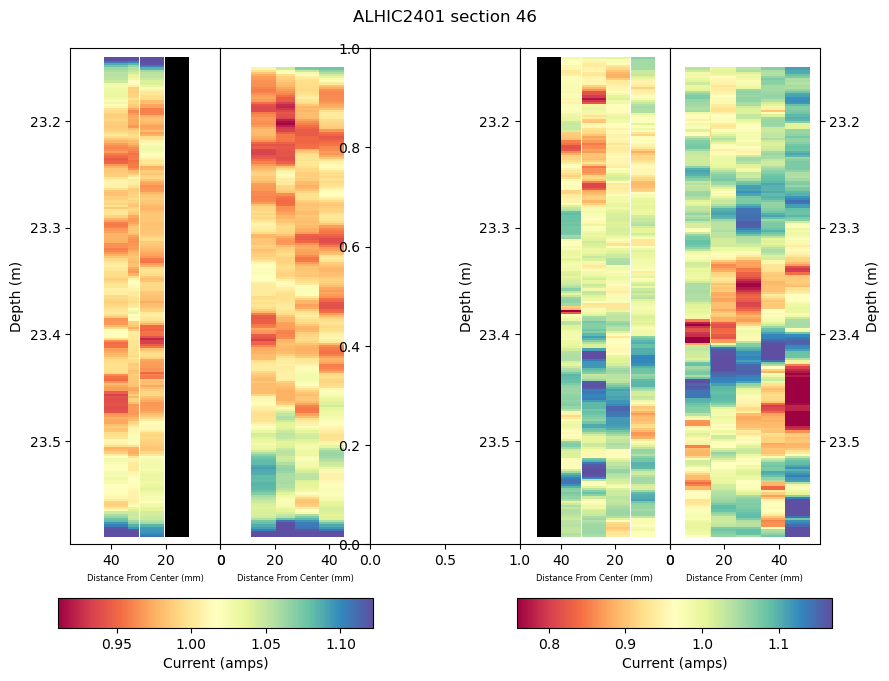

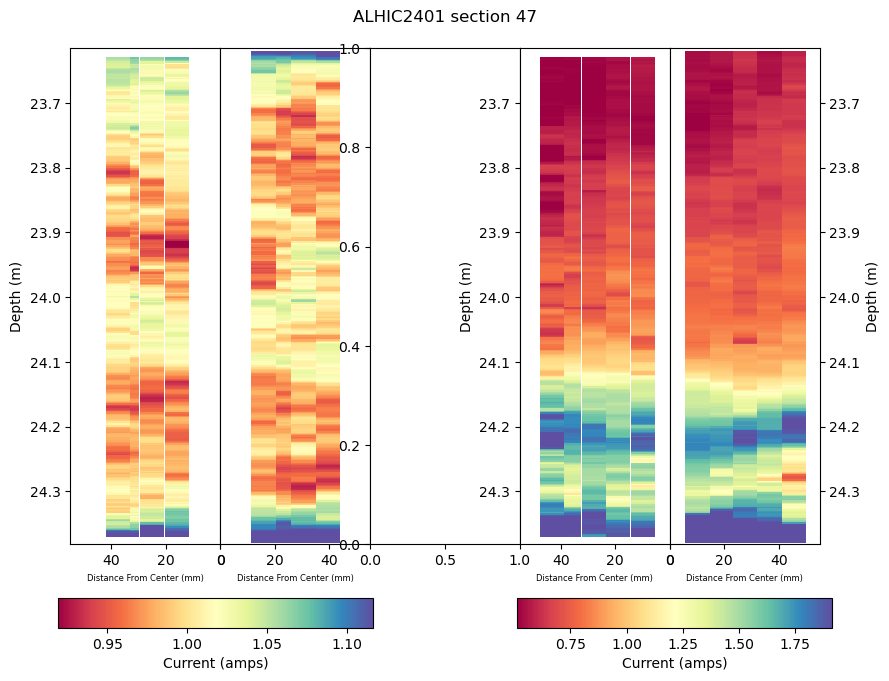

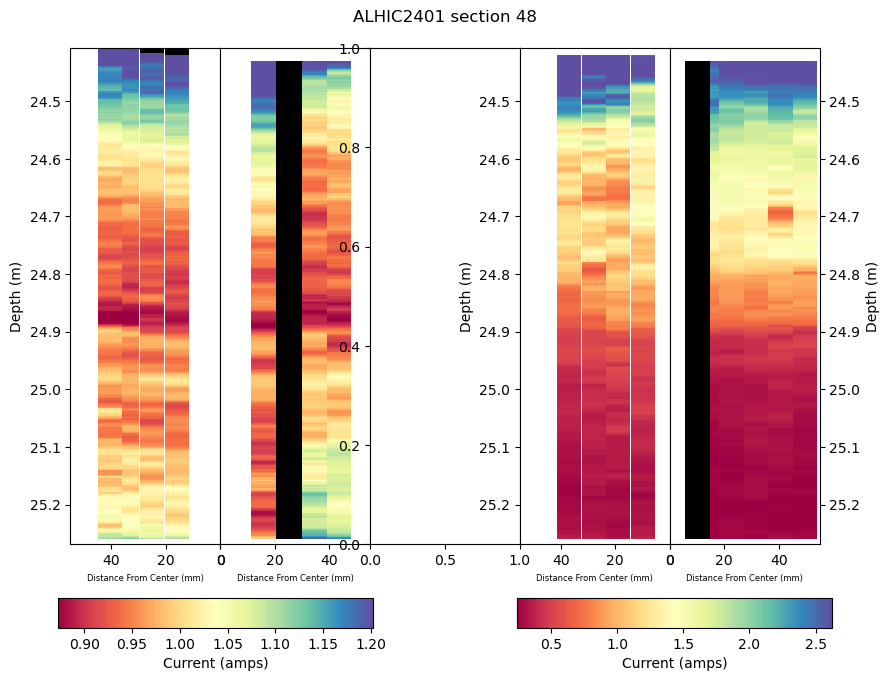

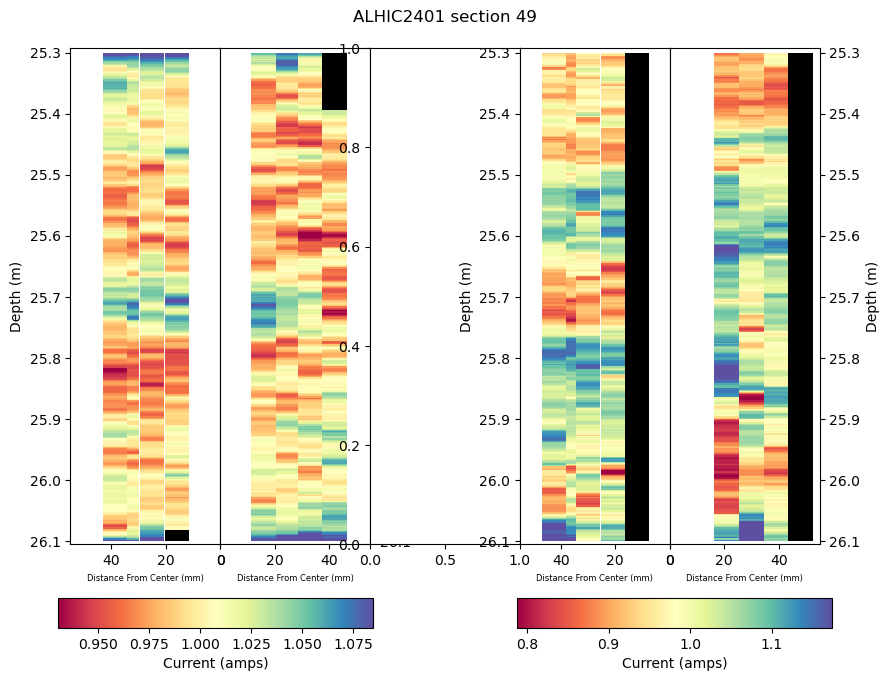

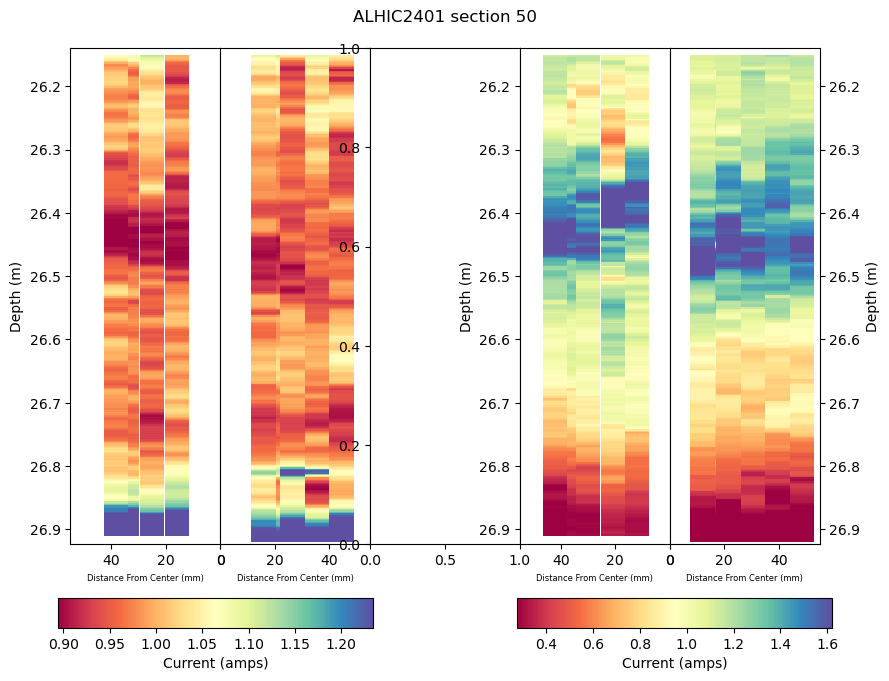

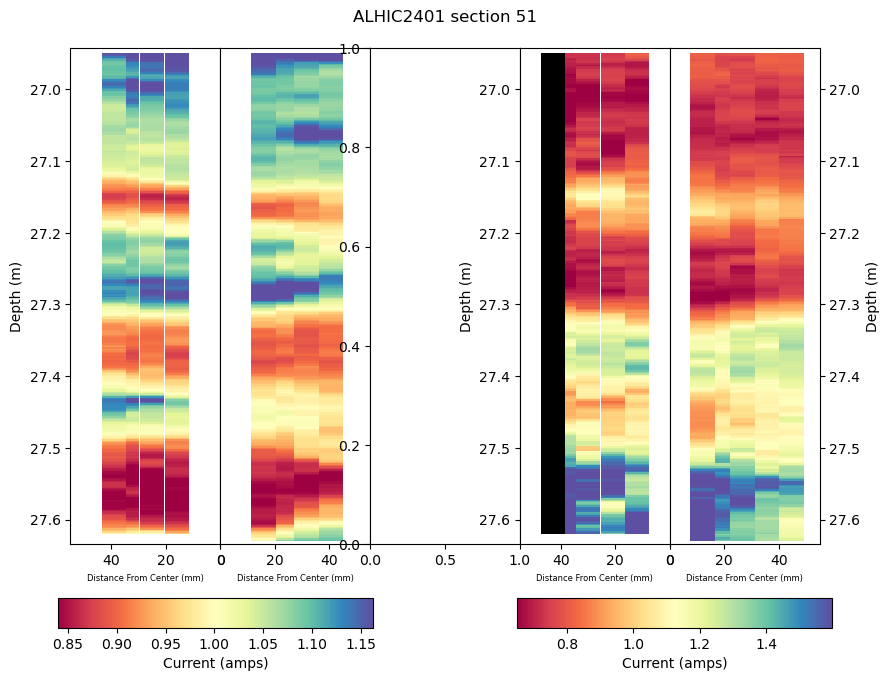

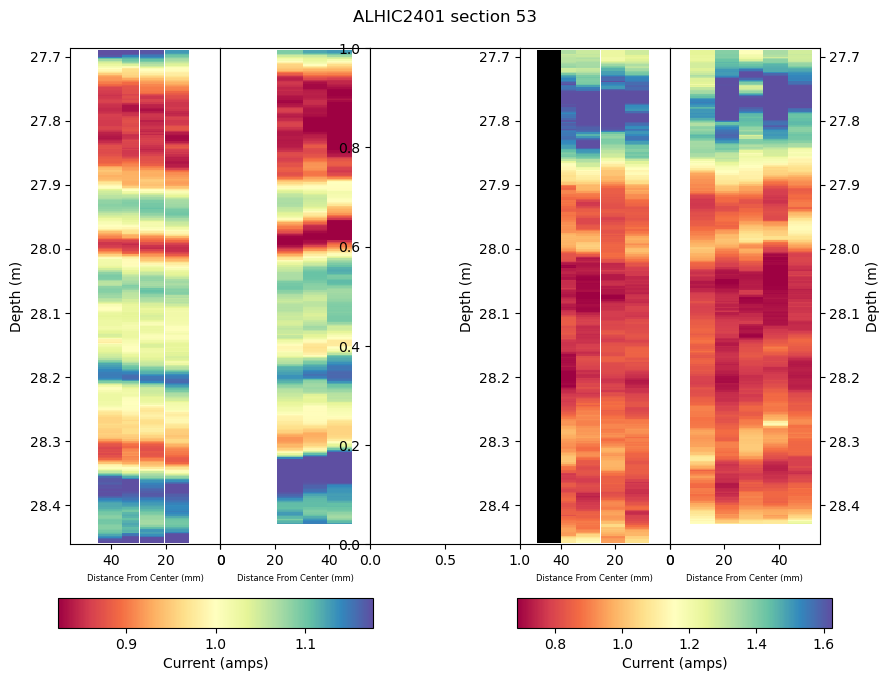

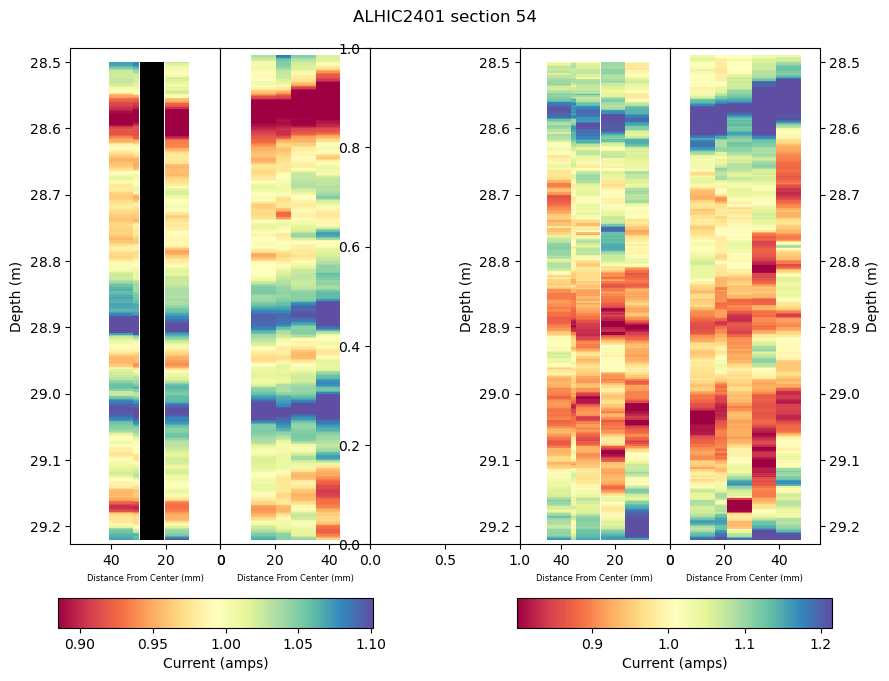

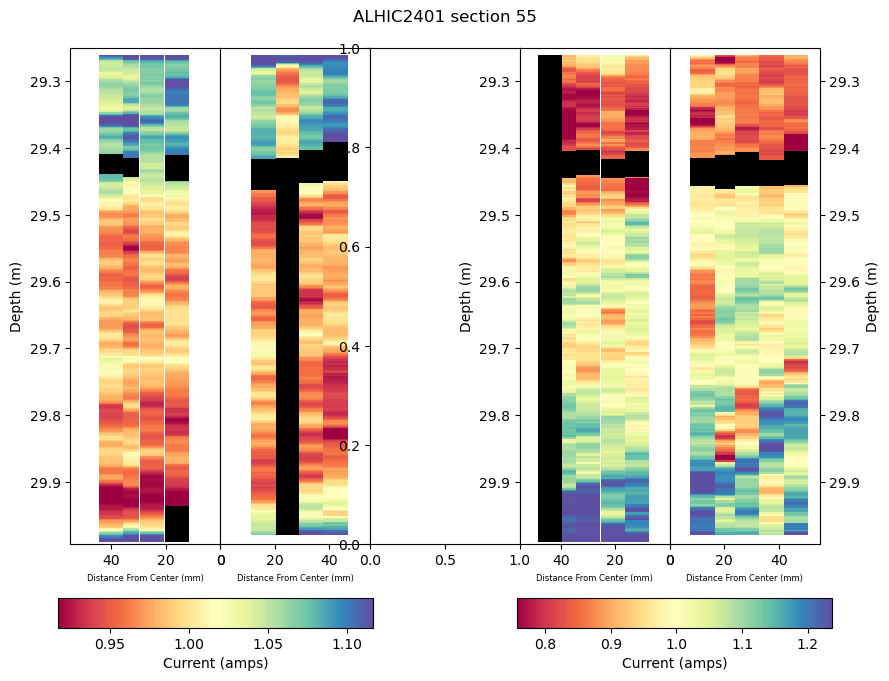

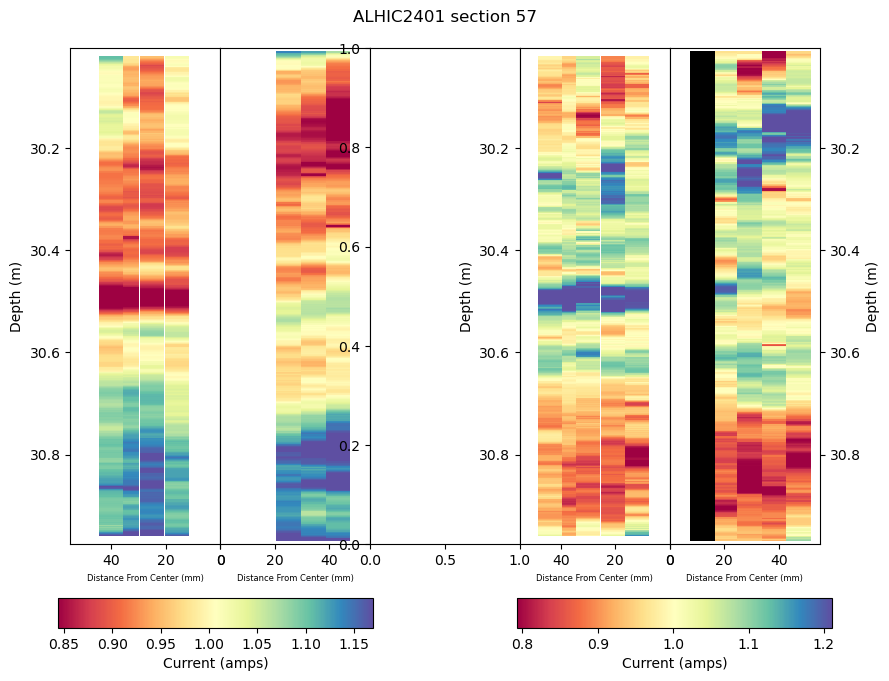

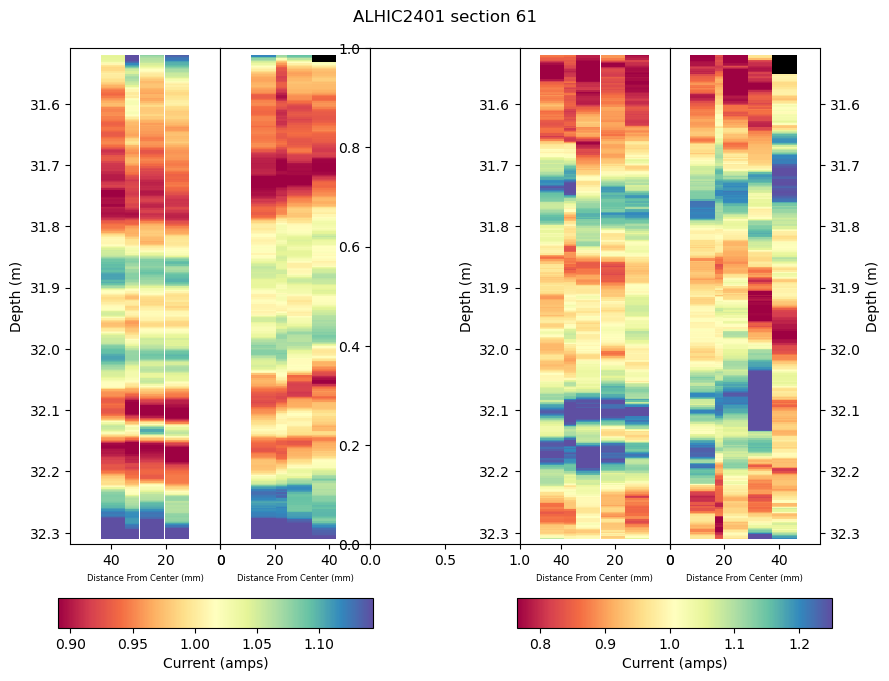

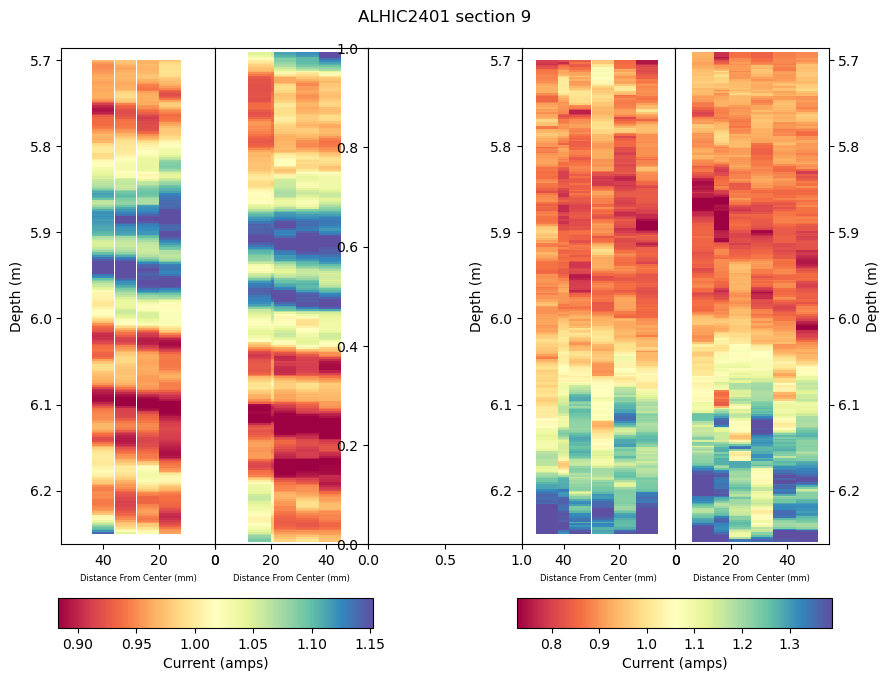

In [42]:
plot_basic('ALHIC2401')

../../data/
Plotting ALHIC2501 section 1, 0 of 189
    Loading ECM data for core: ALHIC2501, section: 1, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2501, section: 1, face: w1, ACorDC: DC
Plotting ALHIC2501 section 10, 1 of 189
    Loading ECM data for core: ALHIC2501, section: 10, face: w1, ACorDC: AC
    Loading ECM data for core: ALHIC2501, section: 10, face: w1, ACorDC: DC


KeyboardInterrupt: 

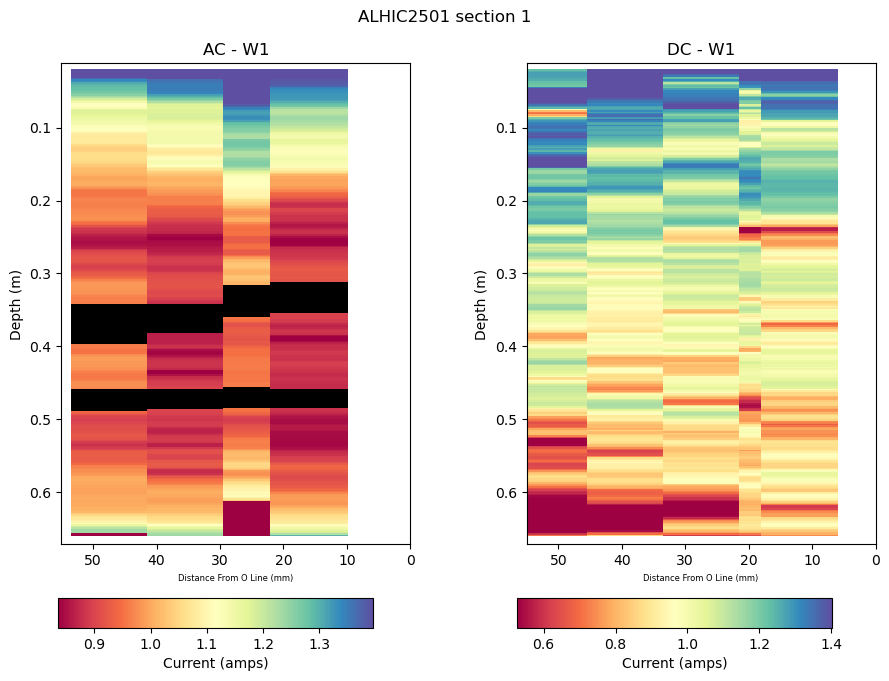

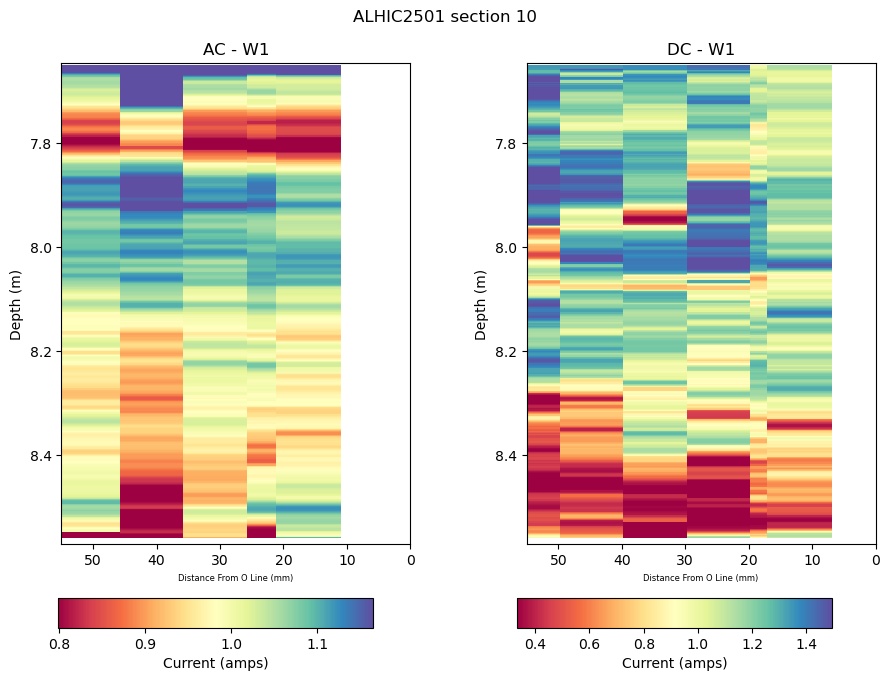

In [32]:
core = 'ALHIC2501'

plot_basic(core)

In [ ]:
faces